## Análise Exploratória dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import STL

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('../data/aapl_history.csv')

df = df.drop(columns=['Unnamed: 0'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

print(f"Período dos dados: {df.index.min()} até {df.index.max()}")
df.head()

Período dos dados: 2024-11-20 00:00:00 até 2025-11-18 00:00:00


,Open,High,Low,Close,Volume
Date,,,,,
2024-11-20,228.06,229.9300,225.8900,229.00,35169566
2024-11-21,228.88,230.1550,225.7103,228.52,42108327
2024-11-22,228.06,230.7199,228.0600,229.87,38168252
2024-11-25,231.46,233.2450,229.7400,232.87,90152832
2024-11-26,233.33,235.5700,233.3300,235.06,45986189


In [3]:
print("Resumo Estatístico:")
display(df.describe())

Resumo Estatístico:


,Open,High,Low,Close,Volume
count,249.000000,249.000000,249.000000,249.000000,2.490000e+02
mean,228.341839,231.019822,225.991172,228.631165,5.461054e+07
std,22.252553,21.907212,22.416168,22.244892,2.325811e+07
min,171.950000,190.335000,169.210100,172.420000,2.323470e+07
25%,210.000000,212.130000,207.720000,210.020000,4.089623e+07
50%,229.220000,232.150000,227.070000,229.720000,4.801327e+07
75%,244.925000,247.240000,243.160400,245.270000,5.736568e+07
max,276.990000,277.320000,272.090000,275.250000,1.843959e+08


### Visualização de Preço e Volume

In [4]:
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])

fig.update_layout(title='Histórico de Preços - Apple (AAPL)', yaxis_title='Preço ($)')
fig.show()

### Série Temporal

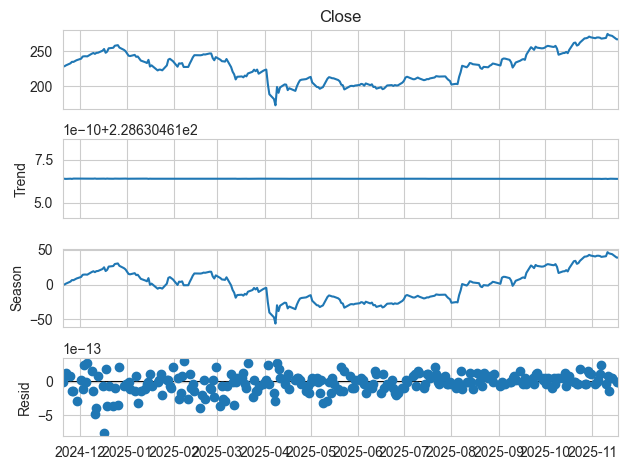

In [5]:
stl = STL(df['Close'], period=252)

result = stl.fit()
result.plot()
plt.show()

### Análise Distribuição Retornos

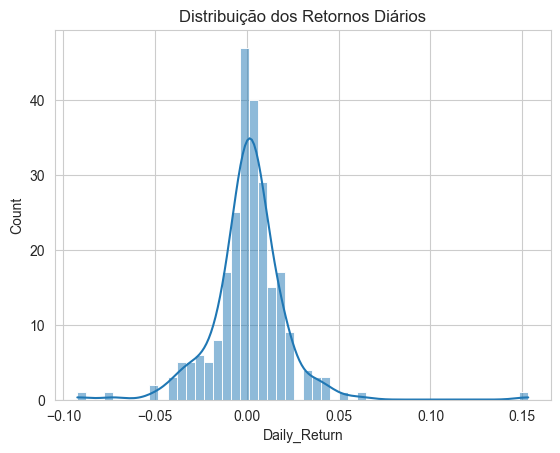

In [6]:
df['Daily_Return'] = df['Close'].pct_change()

sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True)
plt.title('Distribuição dos Retornos Diários')
plt.show()

### Análise de Correlação

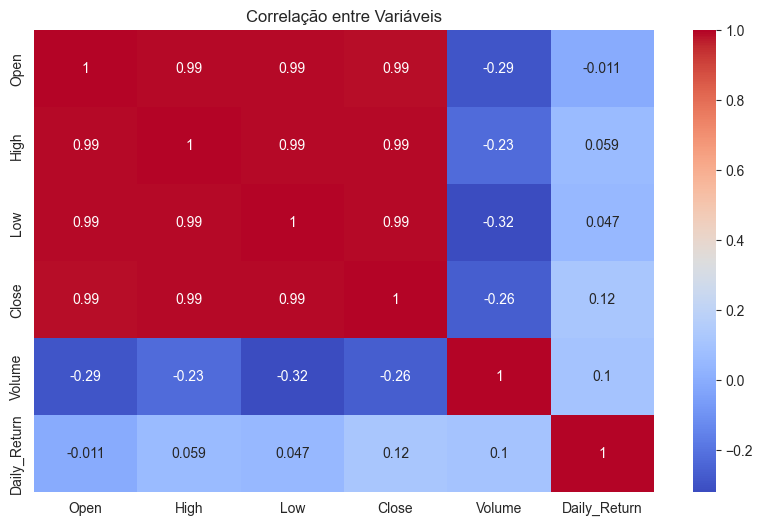

In [7]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlação entre Variáveis")

plt.show()